In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Prompt user to upload the CSV file from local drive
print("Upload your CSV file:")
uploaded = files.upload()

# Load dataset into pandas
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)
print(f"\nDataset loaded successfully. Shape: {df.shape}")
df.head()

Upload your CSV file:


Saving archive.zip to archive.zip

Dataset loaded successfully. Shape: (5000, 14)


,Order ID,Order Date,Customer Name,Region,City,Category,Sub-Category,Product Name,Quantity,Unit Price,Discount,Sales,Profit,Payment Mode
0,10001,2024-10-19,Kashvi Varty,South,Bangalore,Books,Non-Fiction,Non-Fiction Ipsum,2,36294,5,68958.6,10525.09,Debit Card
1,10002,2025-08-30,Advik Desai,North,Delhi,Groceries,Rice,Rice Nemo,1,42165,20,33732.0,6299.66,Debit Card
2,10003,2023-11-04,Rhea Kalla,East,Patna,Kitchen,Juicer,Juicer Odio,4,64876,20,207603.2,19850.27,Credit Card
3,10004,2025-05-23,Anika Sen,East,Kolkata,Groceries,Oil,Oil Doloribus,5,37320,15,158610.0,36311.02,UPI
4,10005,2025-01-19,Akarsh Kaul,West,Pune,Clothing,Kids Wear,Kids Wear Quo,1,50037,10,45033.3,9050.04,Debit Card


In [2]:
# Convert Order Date to standard datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')

# Check for missing values and duplicates
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# Strip leading/trailing whitespaces from string columns
object_cols = df.select_dtypes(include=['object']).columns
df[object_cols] = df[object_cols].apply(lambda x: x.str.strip())

# Fill missing numerical values with median if any exist
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

Missing values per column:
Order ID         0
Order Date       0
Customer Name    0
Region           0
City             0
Category         0
Sub-Category     0
Product Name     0
Quantity         0
Unit Price       0
Discount         0
Sales            0
Profit           0
Payment Mode     0
dtype: int64

Duplicate rows: 0


In [3]:
# Calculate Gross Revenue and Total Revenue
if 'Unit Price' in df.columns and 'Quantity' in df.columns:
    df['Gross Revenue'] = df['Quantity'] * df['Unit Price']

# Extract date features for time-series granularity
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Year_Month'] = df['Order Date'].dt.to_period('M')
df['Day_of_Week'] = df['Order Date'].dt.day_name()

df[['Order Date', 'Gross Revenue', 'Order Year', 'Day_of_Week']].head()

,Order Date,Gross Revenue,Order Year,Day_of_Week
0,2024-10-19,72588,2024,Saturday
1,2025-08-30,42165,2025,Saturday
2,2023-11-04,259504,2023,Saturday
3,2025-05-23,186600,2025,Friday
4,2025-01-19,50037,2025,Sunday


In [4]:
# Numerical statistical summary
print("=== Numerical Summary ===")
display(df.describe().T)

# Top performing categories and regions
print("\n=== Top Product Categories ===")
print(df['Category'].value_counts())

print("\n=== Order Counts by Region ===")
print(df['Region'].value_counts())

=== Numerical Summary ===


,count,mean,min,25%,50%,75%,max,std
Order ID,5000.0,12500.5,10001.0,11250.75,12500.5,13750.25,15000.0,1443.520003
Order Date,5000,2024-09-30 18:58:27.840000,2023-10-04 00:00:00,2024-04-05 00:00:00,2024-09-29 00:00:00,2025-03-30 00:00:00,2025-10-03 00:00:00,NaN
Quantity,5000.0,2.9926,1.0,2.0,3.0,4.0,5.0,1.413133
Unit Price,5000.0,39760.9046,222.0,20312.25,39459.5,59721.75,79998.0,22831.783946
Discount,5000.0,10.051,0.0,5.0,10.0,15.0,20.0,7.084662
Sales,5000.0,106733.20487,264.1,39766.5375,83080.325,156968.5875,398485.0,85108.208202
Profit,5000.0,15941.746982,19.12,4892.295,11108.525,22467.9875,89688.44,14897.684916
Gross Revenue,5000.0,118634.2178,278.0,44950.5,94378.0,173078.25,399400.0,93792.624893
Order Year,5000.0,2024.2532,2023.0,2024.0,2024.0,2025.0,2025.0,0.65542
Order Month,5000.0,6.4798,1.0,4.0,6.0,9.0,12.0,3.443307



=== Top Product Categories ===
Category
Books          528
Kitchen        528
Furniture      527
Home Decor     515
Sports         511
Clothing       511
Toys           478
Electronics    472
Groceries      470
Beauty         460
Name: count, dtype: int64

=== Order Counts by Region ===
Region
North    1288
East     1256
West     1241
South    1215
Name: count, dtype: int64


/tmp/ipykernel_688/1349215696.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_revenue, x='Gross Revenue', y='Category', ax=axes[0, 1], palette='viridis')
/tmp/ipykernel_688/1349215696.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Region', ax=axes[1, 0], palette='Blues_r')
/tmp/ipykernel_688/1349215696.py:21: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Day_of_Week', y='Quantity', order=order_days, ax=axes[1, 1], palette='magma', ci=None)
/tmp/ipykernel_688/1349215696.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assig

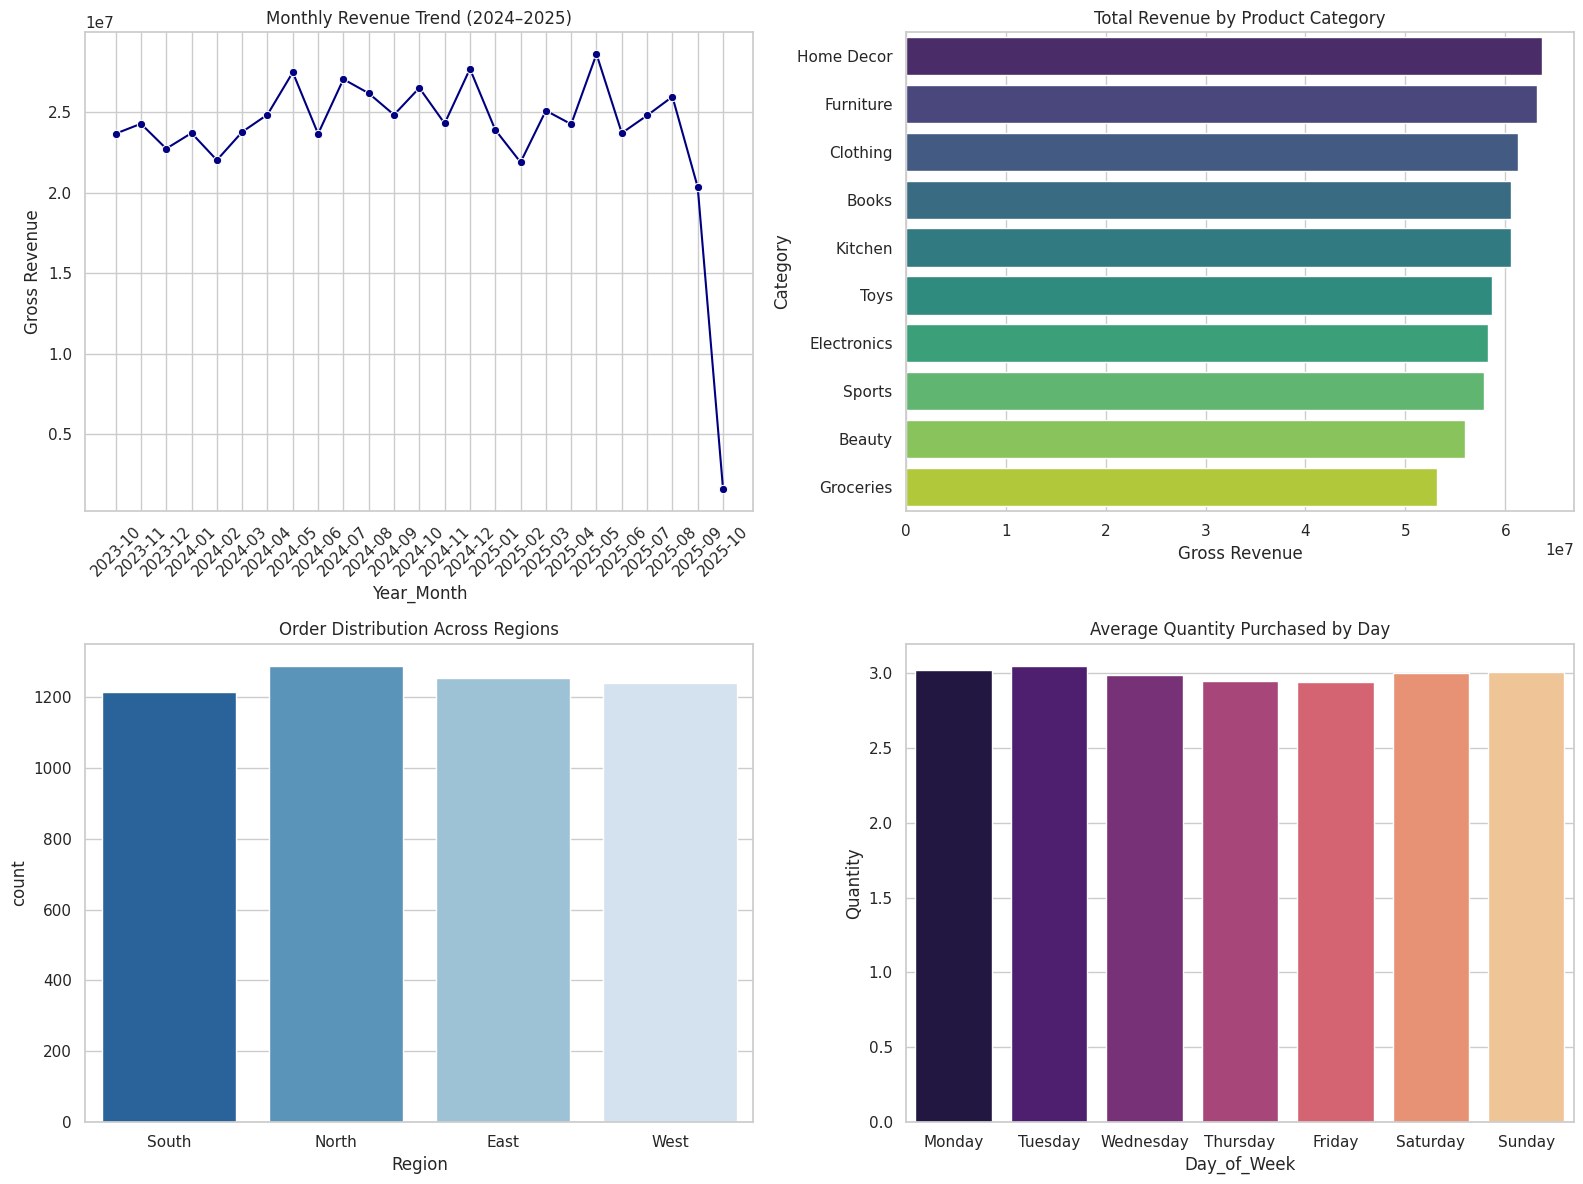

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Chart 1: Monthly Sales Trend (2024 - 2025)
monthly_sales = df.groupby('Year_Month')['Gross Revenue'].sum().reset_index()
monthly_sales['Year_Month'] = monthly_sales['Year_Month'].astype(str)
sns.lineplot(data=monthly_sales, x='Year_Month', y='Gross Revenue', marker='o', ax=axes[0, 0], color='navy')
axes[0, 0].set_title('Monthly Revenue Trend (2024–2025)')
axes[0, 0].tick_params(axis='x', rotation=45)

# Chart 2: Revenue by Product Category
cat_revenue = df.groupby('Category')['Gross Revenue'].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=cat_revenue, x='Gross Revenue', y='Category', ax=axes[0, 1], palette='viridis')
axes[0, 1].set_title('Total Revenue by Product Category')

# Chart 3: Order Volume by Region
sns.countplot(data=df, x='Region', ax=axes[1, 0], palette='Blues_r')
axes[1, 0].set_title('Order Distribution Across Regions')

# Chart 4: Quantity Sold by Day of the Week
order_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.barplot(data=df, x='Day_of_Week', y='Quantity', order=order_days, ax=axes[1, 1], palette='magma', ci=None)
axes[1, 1].set_title('Average Quantity Purchased by Day')

plt.tight_layout()
plt.show()

### Advanced Data Validation

Beyond basic missing values and duplicates, advanced validation involves checking data against business rules and logical constraints. Here, we'll check for:

1.  **Non-negative values**: Ensure `Quantity`, `Unit Price`, `Sales`, `Profit`, and `Discount` are not negative.
2.  **Logical consistency of Sales/Discount/Profit**: Verify if `Sales` and `Profit` align with `Unit Price`, `Quantity`, and `Discount`.


In [6]:
# 1. Check for non-negative values in numerical columns where applicable
negative_check_cols = ['Quantity', 'Unit Price', 'Discount', 'Sales', 'Profit']
for col in negative_check_cols:
    if (df[col] < 0).any():
        print(f"Warning: Negative values found in '{col}'. Count: {(df[col] < 0).sum()}")
    else:
        print(f"'{col}' contains no negative values.")

# 2. Check logical consistency between Sales, Gross Revenue, Discount, and Profit
# Your 'Sales' column already seems to reflect the price after discount.
# Let's verify this and also check profit margins.

# Calculate expected Sales based on Gross Revenue and Discount
df['Calculated_Sales'] = df['Gross Revenue'] * (1 - df['Discount'] / 100)

# Compare with the existing 'Sales' column
difference = (df['Sales'] - df['Calculated_Sales']).abs()
if (difference > 0.01).any(): # Allowing for minor floating point discrepancies
    print(f"Warning: Discrepancies found between 'Sales' and 'Calculated_Sales'. Total discrepancies: {(difference > 0.01).sum()}")
    display(df[difference > 0.01][['Gross Revenue', 'Discount', 'Sales', 'Calculated_Sales']].head())
else:
    print("Sales and Calculated_Sales are consistent (within a small tolerance).")

# Check if Profit exceeds Sales (which is usually an anomaly unless Sales refers to revenue after returns and profit is something else)
if (df['Profit'] > df['Sales']).any():
    print(f"Warning: Profit exceeds Sales for some records. Count: {(df['Profit'] > df['Sales']).sum()}")
    display(df[df['Profit'] > df['Sales']][['Sales', 'Profit']].head())
else:
    print("Profit does not exceed Sales for any record.")

# Remove the temporary 'Calculated_Sales' column
df = df.drop(columns=['Calculated_Sales'])

'Quantity' contains no negative values.
'Unit Price' contains no negative values.
'Discount' contains no negative values.
'Sales' contains no negative values.
'Profit' contains no negative values.
Sales and Calculated_Sales are consistent (within a small tolerance).
Profit does not exceed Sales for any record.


### Data Aggregation/Summarization

Aggregating data is crucial for performance when dealing with large datasets, as it pre-calculates common metrics. We've already looked at monthly and category-wise sales. Let's create an aggregated table for daily sales and profit by `Region` and `Category`, which could be useful for regional performance analysis.

In [7]:
# Aggregate daily sales and profit by Region and Category
df_daily_agg = df.groupby(['Order Date', 'Region', 'Category']).agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Average_Discount=('Discount', 'mean')
).reset_index()

print("Daily Aggregated Data (by Region and Category):")
display(df_daily_agg.head())

Daily Aggregated Data (by Region and Category):


,Order Date,Region,Category,Total_Sales,Total_Profit,Average_Discount
0,2023-10-04,East,Home Decor,18518.4,2273.75,20.0
1,2023-10-04,North,Sports,6458.4,724.54,10.0
2,2023-10-04,South,Furniture,77522.4,10882.22,20.0
3,2023-10-04,South,Kitchen,39026.0,6959.45,0.0
4,2023-10-04,South,Sports,56847.0,4259.92,0.0


### Data Normalization/Denormalization for a Data Warehouse

When loading data into a data warehouse, you often structure it into a **star schema** or **snowflake schema**.

*   **Normalization** aims to reduce data redundancy and improve data integrity, often resulting in many smaller, related tables.
*   **Denormalization** (as seen in star schemas) often involves duplicating some data to improve query performance by reducing the number of joins needed.

For a data warehouse, a **star schema** is common:
*   **Fact Table**: Contains quantitative data (measures) and foreign keys to dimension tables.
*   **Dimension Tables**: Contain descriptive attributes related to the measures in the fact table.

Let's illustrate by creating a simple Customer Dimension, Product Dimension, and a Fact Sales table from your `df`.

In [8]:
# 1. Create a Customer Dimension Table
customer_dim = df[['Customer Name', 'Region', 'City']].drop_duplicates().reset_index(drop=True)
customer_dim['customer_id'] = customer_dim.index + 1 # Assign a simple ID

# 2. Create a Product Dimension Table
product_dim = df[['Category', 'Sub-Category', 'Product Name', 'Unit Price']].drop_duplicates().reset_index(drop=True)
product_dim['product_id'] = product_dim.index + 1 # Assign a simple ID

# 3. Create a Date Dimension (simple version)
date_dim = df[['Order Date', 'Order Year', 'Order Month', 'Day_of_Week']].drop_duplicates().reset_index(drop=True)
date_dim['date_id'] = date_dim.index + 1 # Assign a simple ID

# Display the head of the new dimension tables
print("Customer Dimension:")
display(customer_dim.head())

print("\nProduct Dimension:")
display(product_dim.head())

print("\nDate Dimension:")
display(date_dim.head())

Customer Dimension:


,Customer Name,Region,City,customer_id
0,Kashvi Varty,South,Bangalore,1
1,Advik Desai,North,Delhi,2
2,Rhea Kalla,East,Patna,3
3,Anika Sen,East,Kolkata,4
4,Akarsh Kaul,West,Pune,5



Product Dimension:


,Category,Sub-Category,Product Name,Unit Price,product_id
0,Books,Non-Fiction,Non-Fiction Ipsum,36294,1
1,Groceries,Rice,Rice Nemo,42165,2
2,Kitchen,Juicer,Juicer Odio,64876,3
3,Groceries,Oil,Oil Doloribus,37320,4
4,Clothing,Kids Wear,Kids Wear Quo,50037,5



Date Dimension:


,Order Date,Order Year,Order Month,Day_of_Week,date_id
0,2024-10-19,2024,10,Saturday,1
1,2025-08-30,2025,8,Saturday,2
2,2023-11-04,2023,11,Saturday,3
3,2025-05-23,2025,5,Friday,4
4,2025-01-19,2025,1,Sunday,5


In [9]:
# 4. Create a Fact Sales Table
# Merge the dimension IDs back into the main DataFrame
fact_sales = df.merge(customer_dim[['Customer Name', 'customer_id']], on='Customer Name', how='left')
fact_sales = fact_sales.merge(product_dim[['Product Name', 'product_id']], on='Product Name', how='left')
fact_sales = fact_sales.merge(date_dim[['Order Date', 'date_id']], on='Order Date', how='left')

# Select relevant columns for the fact table (measures and foreign keys)
fact_sales = fact_sales[['Order ID', 'customer_id', 'product_id', 'date_id',
                         'Quantity', 'Discount', 'Sales', 'Profit', 'Gross Revenue', 'Payment Mode']]

print("Fact Sales Table (showing foreign keys and measures):")
display(fact_sales.head())

print("\nThis demonstrates how you can structure your data for a data warehouse. In a real scenario, these tables would be loaded into your chosen data warehouse system (e.g., BigQuery, Snowflake).")

Fact Sales Table (showing foreign keys and measures):


,Order ID,customer_id,product_id,date_id,Quantity,Discount,Sales,Profit,Gross Revenue,Payment Mode
0,10001,1,1,1,2,5,68958.6,10525.09,72588,Debit Card
1,10001,1,1188,1,2,5,68958.6,10525.09,72588,Debit Card
2,10002,2,2,2,1,20,33732.0,6299.66,42165,Debit Card
3,10002,2,760,2,1,20,33732.0,6299.66,42165,Debit Card
4,10003,3,3,3,4,20,207603.2,19850.27,259504,Credit Card



This demonstrates how you can structure your data for a data warehouse. In a real scenario, these tables would be loaded into your chosen data warehouse system (e.g., BigQuery, Snowflake).


## Generating a PDF Report

We will create a PDF report summarizing the data analysis, including key statistics and visualizations.

In [20]:
# Install the FPDF library if you haven't already
%pip install fpdf

### 1. Prepare Visualizations for the Report

To include plots in the PDF, we need to save them as image files (e.g., PNG). We'll regenerate the main visualization from earlier and save it.

In [22]:
from fpdf import FPDF

# Ensure the plots directory exists
import os
if not os.path.exists('report_images'):
    os.makedirs('report_images')

# Regenerate and save the main visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Chart 1: Monthly Sales Trend (2024 - 2025)
monthly_sales = df.groupby('Year_Month')['Gross Revenue'].sum().reset_index()
monthly_sales['Year_Month'] = monthly_sales['Year_Month'].astype(str)
sns.lineplot(data=monthly_sales, x='Year_Month', y='Gross Revenue', marker='o', ax=axes[0, 0], color='navy')
axes[0, 0].set_title('Monthly Revenue Trend (2024–2025)')
axes[0, 0].tick_params(axis='x', rotation=45)

# Chart 2: Revenue by Product Category
cat_revenue = df.groupby('Category')['Gross Revenue'].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=cat_revenue, x='Gross Revenue', y='Category', ax=axes[0, 1], palette='viridis')
axes[0, 1].set_title('Total Revenue by Product Category')

# Chart 3: Order Volume by Region
sns.countplot(data=df, x='Region', ax=axes[1, 0], palette='Blues_r')
axes[1, 0].set_title('Order Distribution Across Regions')

# Chart 4: Quantity Sold by Day of the Week
order_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.barplot(data=df, x='Day_of_Week', y='Quantity', order=order_days, ax=axes[1, 1], palette='magma', errorbar=None) # Changed ci=None to errorbar=None
axes[1, 1].set_title('Average Quantity Purchased by Day')

plt.tight_layout()
plt.savefig('report_images/overall_dashboard.png', dpi=300) # Increased DPI for better quality
plt.close(fig) # Close the figure to prevent it from displaying twice
print("Overall dashboard saved as 'report_images/overall_dashboard.png'")

/tmp/ipykernel_688/3202128551.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_revenue, x='Gross Revenue', y='Category', ax=axes[0, 1], palette='viridis')
/tmp/ipykernel_688/3202128551.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Region', ax=axes[1, 0], palette='Blues_r')
/tmp/ipykernel_688/3202128551.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Day_of_Week', y='Quantity', order=order_days, ax=axes[1, 1], palette='magma', errorbar=None) # Changed ci=None to errorbar=None


Overall dashboard saved as 'report_images/overall_dashboard.png'


### 2. Define the PDF Report Class and Generate the Report

We'll create a custom PDF class to manage headers and footers, and then add content section by section.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from fpdf import FPDF
import os

# Ensure the plots directory exists
if not os.path.exists('report_images'):
    os.makedirs('report_images')

# Assuming df is already loaded and preprocessed from your previous steps.
# Regenerate and save the main visualization dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

monthly_sales = df.groupby('Year_Month')['Gross Revenue'].sum().reset_index()
monthly_sales['Year_Month'] = monthly_sales['Year_Month'].astype(str)
sns.lineplot(data=monthly_sales, x='Year_Month', y='Gross Revenue', marker='o', ax=axes[0, 0], color='navy')
axes[0, 0].set_title('Monthly Revenue Trend (2024–2025)')
axes[0, 0].tick_params(axis='x', rotation=45)

cat_revenue = df.groupby('Category')['Gross Revenue'].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=cat_revenue, x='Gross Revenue', y='Category', ax=axes[0, 1], palette='viridis')
axes[0, 1].set_title('Total Revenue by Product Category')

sns.countplot(data=df, x='Region', ax=axes[1, 0], palette='Blues_r')
axes[1, 0].set_title('Order Distribution Across Regions')

order_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.barplot(data=df, x='Day_of_Week', y='Quantity', order=order_days, ax=axes[1, 1], palette='magma', errorbar=None)
axes[1, 1].set_title('Average Quantity Purchased by Day')

plt.tight_layout()
plt.savefig('report_images/overall_dashboard.png', dpi=300)
plt.close(fig)

class PDF(FPDF):
    def header(self):
        self.set_font('Arial', 'B', 15)
        self.cell(0, 10, 'E-commerce Sales Data Analysis Report', 0, 1, 'C')
        self.ln(10)

    def footer(self):
        self.set_y(-15)
        self.set_font('Arial', 'I', 8)
        self.cell(0, 10, f'Page {self.page_no()}/{{nb}}', 0, 0, 'C')

    def chapter_title(self, title):
        self.set_font('Arial', 'B', 12)
        self.cell(0, 10, title, 0, 1, 'L')
        self.ln(3)

    def chapter_body(self, body_text):
        self.set_font('Arial', '', 10)
        self.multi_cell(0, 5, body_text)
        self.ln(4)

    def add_split_dataframe_as_table(self, df_to_print, title="", num_rows=5):
        """Splits any dataframe horizontally into two manageable column chunks for clear rendering."""
        if title:
            self.chapter_title(title)

        columns = list(df_to_print.columns)
        mid = len(columns) // 2
        part1_cols = columns[:mid]
        part2_cols = columns[mid:]

        df_part1 = df_to_print[part1_cols].head(num_rows)
        df_part2 = df_to_print[part2_cols].head(num_rows)

        row_height = 7

        # --- Render Part 1 Table ---
        self.set_font('Arial', 'B', 8)
        col_width_1 = (self.w - 20) / len(df_part1.columns)
        for col in df_part1.columns:
            self.cell(col_width_1, row_height, str(col)[:15], border=1, align='C')
        self.ln(row_height)

        self.set_font('Arial', '', 7)
        for _, row in df_part1.iterrows():
            for col in df_part1.columns:
                val = str(row[col])
                if len(val) > 18:
                    val = val[:15] + '...'
                self.cell(col_width_1, row_height, val, border=1, align='C')
            self.ln(row_height)

        self.ln(5)

        # --- Render Part 2 Table ---
        self.set_font('Arial', 'B', 8)
        col_width_2 = (self.w - 20) / len(df_part2.columns)
        for col in df_part2.columns:
            self.cell(col_width_2, row_height, str(col)[:15], border=1, align='C')
        self.ln(row_height)

        self.set_font('Arial', '', 7)
        for _, row in df_part2.iterrows():
            for col in df_part2.columns:
                val = str(row[col])
                if len(val) > 18:
                    val = val[:15] + '...'
                self.cell(col_width_2, row_height, val, border=1, align='C')
            self.ln(row_height)

        self.ln(6)

# Initialize PDF
pdf = PDF()
pdf.alias_nb_pages()
pdf.add_page()

# --- Introduction ---
pdf.chapter_title('1. Introduction')
pdf.chapter_body(
    "This report presents an analysis of E-commerce Sales Data for the years 2024-2025. "
    "It covers data loading, cleaning, feature engineering, exploratory data analysis, "
    "advanced data validation, aggregation, and data warehousing schema design."
)

# --- Data Overview ---
pdf.chapter_title('2. Data Overview and Preprocessing')
pdf.chapter_body(
    "The dataset contains transaction records including order details, customer information, "
    "product data, and sales figures. Initial preprocessing included format standardization and missing value audits."
)

# Raw Data Sample split into two visual parts
pdf.add_split_dataframe_as_table(df.head(5), title="2.1 Raw Data Sample (Split View)")

# Numerical Summary cleanup and split formatting
describe_df = df.describe().T.reset_index()
describe_df.columns = ['Metric', 'Count', 'Mean', 'Std', 'Min', '25%', '50%', '75%', 'Max']
numeric_cols = ['Count', 'Mean', 'Std', 'Min', '25%', '50%', '75%', 'Max']
describe_df[numeric_cols] = describe_df[numeric_cols].round(2)

pdf.add_split_dataframe_as_table(describe_df, title="2.2 Numerical Summary (Split View)", num_rows=10)

# --- Visualizations ---
pdf.add_page()
pdf.chapter_title('3. Key Visualizations Dashboard')
pdf.chapter_body(
    "The dashboard below summarizes monthly revenue trajectories, top revenue categories, "
    "regional order counts, and daily shopping volumes."
)

image_path = 'report_images/overall_dashboard.png'
if os.path.exists(image_path):
    pdf.image(image_path, x=10, y=pdf.get_y(), w=190)

# Save PDF
pdf_file_name = 'E_commerce_Sales_Analysis_Report.pdf'
pdf.output(pdf_file_name)
print(f"Report generated successfully: {pdf_file_name}")

# Trigger download in Colab
files.download(pdf_file_name)

/tmp/ipykernel_688/4009930160.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_revenue, x='Gross Revenue', y='Category', ax=axes[0, 1], palette='viridis')
/tmp/ipykernel_688/4009930160.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Region', ax=axes[1, 0], palette='Blues_r')
/tmp/ipykernel_688/4009930160.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Day_of_Week', y='Quantity', order=order_days, ax=axes[1, 1], palette='magma', errorbar=None)


Report generated successfully: E_commerce_Sales_Analysis_Report.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
# --- Descriptive Statistics Cleanup ---
pdf.chapter_title('2.2 Numerical Summary')
pdf.chapter_body(
    "Below is a statistical summary of the numerical features in the dataset."
)

# Generate describe, drop non-numeric/datetime rows, and round floats
describe_df = df.describe().T.reset_index()
describe_df.columns = ['Metric', 'Count', 'Mean', 'Std', 'Min', '25%', '50%', '75%', 'Max']

# Round numeric columns to 2 decimal places to fit table cells cleanly
numeric_cols = ['Count', 'Mean', 'Std', 'Min', '25%', '50%', '75%', 'Max']
describe_df[numeric_cols] = describe_df[numeric_cols].round(2)

pdf.add_dataframe_as_table(describe_df, num_rows=10)

### Download the Generated PDF

To download the `E_commerce_Sales_Analysis_Report.pdf` file to your local computer, run the following code cell. You can then upload this file to your GitHub repository.

In [26]:
from google.colab import files

# Assuming the PDF was named 'E_commerce_Sales_Analysis_Report.pdf'
files.download('E_commerce_Sales_Analysis_Report.pdf')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>